# КИМ 7.1. Оптимизаторы и управление скоростью обучения — эталонное решение

> **Это эталонное решение** для преподавателя. Студентам выдаётся ноутбук-задание
> [`kim-07-optimizers.ipynb`](./kim-07-optimizers.ipynb) без заполненных ячеек.
>
> Код ниже — один из возможных вариантов решения; не единственный и не обязательно
> оптимальный. Приводится для сверки и подготовки к защите.

В решении используется **PyTorch**. Все эксперименты проводят на одном
разбиении Fashion-MNIST и начинают с одной и той же копии начальных весов. Это
важно: иначе различия случайной инициализации и порядка батчей можно ошибочно
принять за различия оптимизаторов.

Полный набор экспериментов занимает несколько минут на современной видеокарте и
дольше на CPU. Число эпох намеренно невелико, но Adam/AdamW обычно успевают
достичь test accuracy около 0.88 (результат немного зависит от версий библиотек и
оборудования).

---
## Часть А. Сравнение оптимизаторов

### 0. Импорт, выбор устройства и воспроизводимость

In [1]:
import copy
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

%matplotlib inline

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Детерминированность важнее небольшой прибавки скорости в учебном сравнении.
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print(f"Устройство: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Устройство: cuda
GPU: NVIDIA GeForce GTX 1080 Ti


`torch.manual_seed` фиксирует генератор CPU, а
`torch.cuda.manual_seed_all` — генераторы CUDA. Детерминированные алгоритмы
снижают разброс повторных запусков. Полная побитовая воспроизводимость между
разными версиями PyTorch, CUDA и разным оборудованием всё же не гарантируется.

### 1. Загрузка и фиксированное разбиение Fashion-MNIST

In [2]:
# ToTensor переводит uint8-пиксели в float32 и масштабирует их в [0, 1].
# Затем используем известные среднее и стандартное отклонение Fashion-MNIST.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

data_root = Path("data")
full_train = datasets.FashionMNIST(
    root=data_root, train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root=data_root, train=False, download=True, transform=transform
)

# Одно разбиение 50 000 / 10 000 используется во всех экспериментах.
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train, [50_000, 10_000], generator=split_generator
)

BATCH_SIZE = 512
NUM_WORKERS = min(2, os.cpu_count() or 1)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

def make_loader(dataset, *, shuffle, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=generator,
    )

# Для каждого запуска train loader создаётся заново с тем же seed. Поэтому
# оптимизаторы видят одинаковый порядок объектов. Val/test не перемешиваются.
val_loader = make_loader(val_dataset, shuffle=False)
test_loader = make_loader(test_dataset, shuffle=False)
print(len(train_dataset), len(val_dataset), len(test_dataset))

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<02:17, 192kB/s]

  1%|          | 164k/26.4M [00:00<00:51, 512kB/s] 

  2%|▏         | 524k/26.4M [00:00<00:27, 928kB/s]

  5%|▍         | 1.21M/26.4M [00:00<00:11, 2.23MB/s]

...

100%|██████████| 4.42M/4.42M [00:01<00:00, 3.55MB/s]

Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 16.4MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw

50000 10000 10000


Метки остаются целыми индексами классов от 0 до 9: one-hot encoding
для `nn.CrossEntropyLoss` не нужен.

### 2. Общая MLP и одинаковые начальные веса

In [3]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.layers(x)

def build_model():
    return FashionMLP()

# Эту единственную инициализацию копируем перед каждым экспериментом.
set_seed()
initial_model = build_model()
INITIAL_WEIGHTS = copy.deepcopy(initial_model.state_dict())
del initial_model

def fresh_model():
    # Повторный seed также синхронизирует последовательность масок Dropout.
    set_seed()
    model = build_model()
    model.load_state_dict(INITIAL_WEIGHTS)
    return model.to(DEVICE)

model = fresh_model()
print(model)
del model

FashionMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


Последний слой возвращает **логиты**, поэтому после него нет
`Softmax`. `nn.CrossEntropyLoss` численно устойчиво применяет `LogSoftmax` внутри
себя. Явный `Softmax` перед этой функцией потерь был бы ошибкой.

### 3. Переиспользуемые циклы обучения и оценки

In [4]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    loss_sum = 0.0
    correct = 0
    count = 0

    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
        targets = targets.to(DEVICE, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        count += batch_size

    return loss_sum / count, correct / count

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()  # отключает Dropout
    loss_sum = 0.0
    correct = 0
    count = 0

    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=PIN_MEMORY)
        targets = targets.to(DEVICE, non_blocking=PIN_MEMORY)
        logits = model(inputs)
        loss = criterion(logits, targets)

        batch_size = targets.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == targets).sum().item()
        count += batch_size

    return loss_sum / count, correct / count

def fit(
    model,
    optimizer,
    epochs,
    *,
    train_loader,
    scheduler=None,
    scheduler_on_plateau=False,
    verbose=False,
):
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [], "lr": [],
    }

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if scheduler is not None:
            if scheduler_on_plateau:
                # ReduceLROnPlateau принимает измеренную validation loss.
                scheduler.step(val_loss)
            else:
                # CosineAnnealingLR делает шаг один раз после каждой эпохи.
                scheduler.step()

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs}: "
                f"loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
                f"val_acc={val_acc:.4f}, lr={current_lr:.2e}"
            )

    return history

def print_metrics(rows):
    print(f'{"эксперимент":<24} {"val_loss":>10} {"val_acc":>10} '
          f'{"test_loss":>10} {"test_acc":>10} {"сек":>8}')
    print("-" * 78)
    for row in rows:
        print(
            f'{row["name"]:<24} {row["val_loss"]:>10.4f} '
            f'{row["val_acc"]:>10.4f} {row["test_loss"]:>10.4f} '
            f'{row["test_acc"]:>10.4f} {row["seconds"]:>8.1f}'
        )

Loss суммируется с весом размера батча, а затем делится на число
примеров. Так последний неполный батч не получает непропорционально большой вес.
`model.eval()` обязателен для корректной оценки сети с Dropout.

### 4. SGD, momentum, Adam, AdamW и RMSProp

In [5]:
# Для SGD нужен заметно больший lr, чем для адаптивных методов.
# Значения явно указаны, чтобы протокол можно было воспроизвести.
optimizer_specs = {
    "SGD": (5e-2, lambda params: torch.optim.SGD(params, lr=5e-2)),
    "SGD + momentum": (
        5e-2,
        lambda params: torch.optim.SGD(params, lr=5e-2, momentum=0.9),
    ),
    "Adam": (1e-3, lambda params: torch.optim.Adam(params, lr=1e-3)),
    "AdamW": (
        1e-3,
        lambda params: torch.optim.AdamW(
            params, lr=1e-3, weight_decay=1e-2
        ),
    ),
    "RMSProp": (1e-3, lambda params: torch.optim.RMSprop(params, lr=1e-3)),
}

OPTIMIZER_EPOCHS = 10
optimizer_histories = {}
optimizer_results = []

for name, (lr, make_optimizer) in optimizer_specs.items():
    model = fresh_model()
    optimizer = make_optimizer(model.parameters())
    train_loader = make_loader(train_dataset, shuffle=True, seed=SEED)

    started = time.perf_counter()
    history = fit(
        model,
        optimizer,
        OPTIMIZER_EPOCHS,
        train_loader=train_loader,
    )
    seconds = time.perf_counter() - started
    test_loss, test_acc = evaluate(model, test_loader)

    optimizer_histories[name] = history
    optimizer_results.append({
        "name": f"{name} (lr={lr:g})",
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "test_loss": test_loss,
        "test_acc": test_acc,
        "seconds": seconds,
    })

print_metrics(optimizer_results)

/home/sheka/miniforge3/envs/onn/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


эксперимент                val_loss    val_acc  test_loss   test_acc      сек
------------------------------------------------------------------------------
SGD (lr=0.05)                0.3937     0.8619     0.4149     0.8484     47.8
SGD + momentum (lr=0.05)     0.3041     0.8920     0.3327     0.8830     49.2
Adam (lr=0.001)              0.3143     0.8843     0.3392     0.8766     49.0
AdamW (lr=0.001)             0.3122     0.8839     0.3385     0.8774     48.3
RMSProp (lr=0.001)           0.3070     0.8876     0.3297     0.8803     47.8


Тестовый набор оценивается только после обучения и не участвует в
выборе параметров. Для честного сравнения совпадают архитектура, начальные веса,
разбиение, порядок батчей, маски Dropout, batch size и число эпох. Learning rate
указан рядом с названием: алгоритм и его масштаб шага нельзя интерпретировать как
один и тот же фактор.

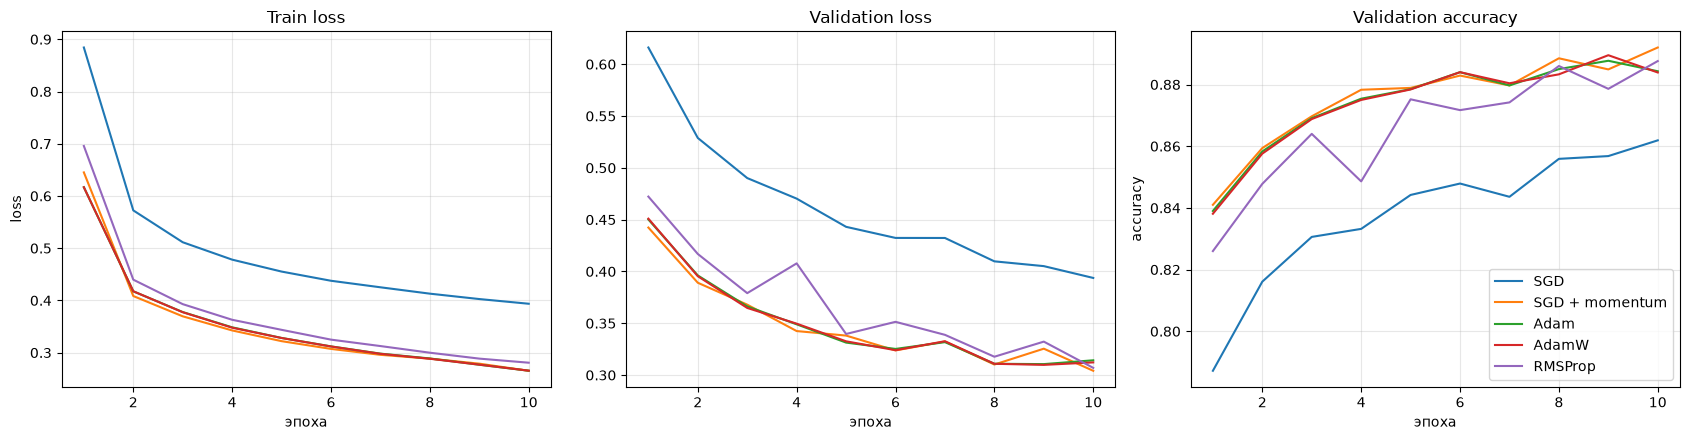

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for name, history in optimizer_histories.items():
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], label=name)
    axes[1].plot(epochs, history["val_loss"], label=name)
    axes[2].plot(epochs, history["val_acc"], label=name)

axes[0].set_title("Train loss")
axes[1].set_title("Validation loss")
axes[2].set_title("Validation accuracy")
for axis in axes:
    axis.set_xlabel("эпоха")
    axis.grid(alpha=0.3)
axes[0].set_ylabel("loss")
axes[2].set_ylabel("accuracy")
axes[2].legend()
plt.tight_layout()
plt.show()

**Ответ (SGD, momentum и адаптивные методы).** Обычный SGD делает
одинаково масштабированный шаг для всех параметров. Momentum накапливает
экспоненциально сглаженное направление градиента, ускоряет движение вдоль
устойчивого направления и уменьшает колебания.

RMSProp делит шаг каждого параметра на корень из скользящего среднего квадратов
его градиентов. Adam сочетает такую адаптацию с моментом первого порядка. Поэтому
Adam часто быстро достигает хорошего результата без тщательной настройки. AdamW
отделяет weight decay от градиентного шага Adam, благодаря чему L2-подобная
регуляризация имеет более понятное действие. На некоторых задачах хорошо
настроенный SGD с momentum обобщает лучше, но обычно требует больше эпох.

---
## Часть Б. Управление скоростью обучения

### 5. Сравнение learning rate: 1e-2, 1e-3 и 1e-4

эксперимент                val_loss    val_acc  test_loss   test_acc      сек
------------------------------------------------------------------------------
Adam, lr=0.01                0.3677     0.8714     0.3884     0.8652     29.6
Adam, lr=0.001               0.3252     0.8840     0.3492     0.8762     29.5
Adam, lr=0.0001              0.4506     0.8454     0.4666     0.8335     31.6


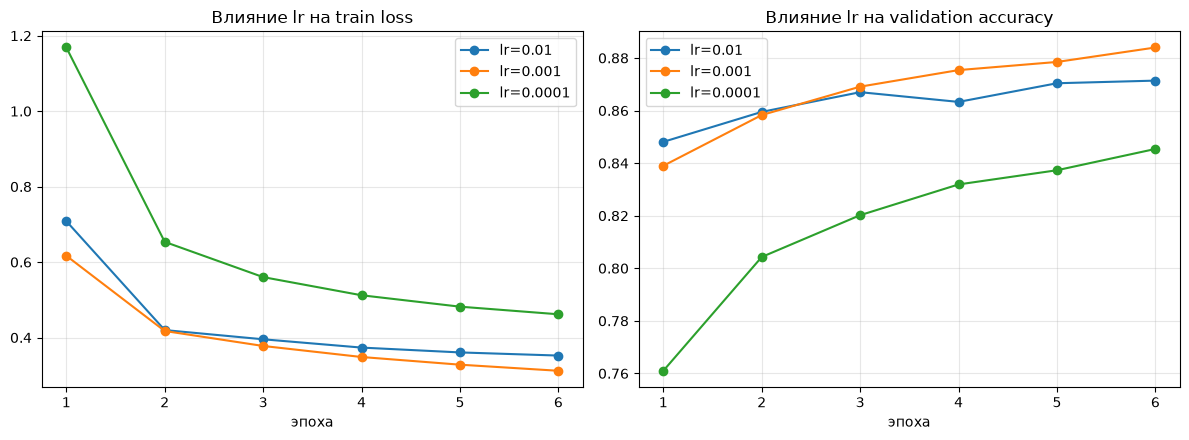

In [7]:
LEARNING_RATES = [1e-2, 1e-3, 1e-4]
LR_EPOCHS = 6
lr_histories = {}
lr_results = []

for lr in LEARNING_RATES:
    model = fresh_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = make_loader(train_dataset, shuffle=True, seed=SEED)

    started = time.perf_counter()
    history = fit(model, optimizer, LR_EPOCHS, train_loader=train_loader)
    seconds = time.perf_counter() - started
    test_loss, test_acc = evaluate(model, test_loader)

    lr_histories[lr] = history
    lr_results.append({
        "name": f"Adam, lr={lr:g}",
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "test_loss": test_loss,
        "test_acc": test_acc,
        "seconds": seconds,
    })

print_metrics(lr_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for lr, history in lr_histories.items():
    epochs = range(1, LR_EPOCHS + 1)
    axes[0].plot(epochs, history["train_loss"], marker="o", label=f"lr={lr:g}")
    axes[1].plot(epochs, history["val_acc"], marker="o", label=f"lr={lr:g}")

axes[0].set_title("Влияние lr на train loss")
axes[1].set_title("Влияние lr на validation accuracy")
for axis in axes:
    axis.set_xlabel("эпоха")
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

Слишком малый `lr=1e-4` обычно даёт плавное, но медленное обучение.
`lr=1e-2` для Adam часто вызывает колебания validation loss или менее устойчивую
сходимость. Для этой архитектуры разумной отправной точкой служит `1e-3`. Вывод
нужно делать по полученным таблице и графикам, а не только по ожидаемому поведению.

### 6. ReduceLROnPlateau и CosineAnnealingLR

In [8]:
SCHEDULER_EPOCHS = 8
scheduler_histories = {}
scheduler_results = []

for strategy in ["constant", "ReduceLROnPlateau", "CosineAnnealingLR"]:
    model = fresh_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    if strategy == "ReduceLROnPlateau":
        # Небольшой patience выбран, чтобы эффект был виден за короткий запуск.
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=0,
            threshold=5e-3,
            threshold_mode="abs",
            min_lr=1e-5,
        )
        scheduler_on_plateau = True
    elif strategy == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=SCHEDULER_EPOCHS, eta_min=1e-5
        )
        scheduler_on_plateau = False
    else:
        scheduler = None
        scheduler_on_plateau = False

    train_loader = make_loader(train_dataset, shuffle=True, seed=SEED)
    started = time.perf_counter()
    history = fit(
        model,
        optimizer,
        SCHEDULER_EPOCHS,
        train_loader=train_loader,
        scheduler=scheduler,
        scheduler_on_plateau=scheduler_on_plateau,
    )
    seconds = time.perf_counter() - started
    test_loss, test_acc = evaluate(model, test_loader)

    scheduler_histories[strategy] = history
    scheduler_results.append({
        "name": strategy,
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "test_loss": test_loss,
        "test_acc": test_acc,
        "seconds": seconds,
    })

print_metrics(scheduler_results)

эксперимент                val_loss    val_acc  test_loss   test_acc      сек
------------------------------------------------------------------------------
constant                     0.3109     0.8850     0.3397     0.8776     41.1
ReduceLROnPlateau            0.3064     0.8881     0.3318     0.8825     40.1
CosineAnnealingLR            0.3233     0.8824     0.3479     0.8778     40.1


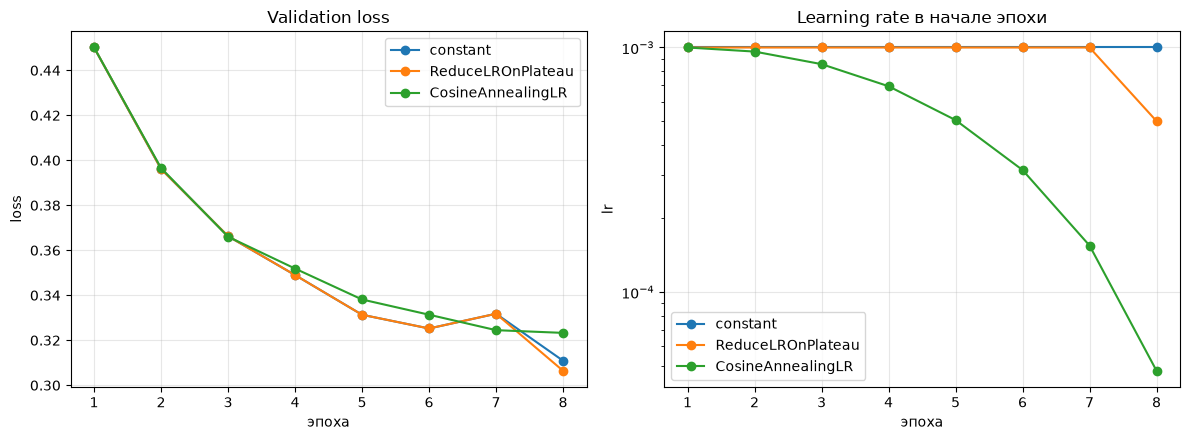

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for strategy, history in scheduler_histories.items():
    epochs = range(1, SCHEDULER_EPOCHS + 1)
    axes[0].plot(epochs, history["val_loss"], marker="o", label=strategy)
    axes[1].plot(epochs, history["lr"], marker="o", label=strategy)

axes[0].set_title("Validation loss")
axes[0].set_xlabel("эпоха")
axes[0].set_ylabel("loss")
axes[1].set_title("Learning rate в начале эпохи")
axes[1].set_xlabel("эпоха")
axes[1].set_ylabel("lr")
axes[1].set_yscale("log")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

`ReduceLROnPlateau` не знает номер «правильной» эпохи: после каждой
эпохи ему явно передаётся измеренный `val_loss` вызовом
`scheduler.step(val_loss)`. Если улучшения нет `patience` эпох, lr умножается на
`factor`. Косинусный scheduler, напротив, заранее задаёт плавную траекторию от
начального lr к `eta_min` и вызывается как `scheduler.step()` без метрики.

Уменьшение шага около минимума позволяет точнее настраивать веса и меньше
перескакивать через хорошие области. Но scheduler не гарантирует улучшение test
accuracy: это проверяется экспериментом.

---
## Часть В. Ручная ранняя остановка

### 7. Early stopping с восстановлением лучших весов

In [10]:
EARLY_STOP_MAX_EPOCHS = 20
EARLY_STOP_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 1e-4

model = fresh_model()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loader = make_loader(train_dataset, shuffle=True, seed=SEED)

early_history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_acc = -float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(1, EARLY_STOP_MAX_EPOCHS + 1):
    train_loss, _ = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)
    early_history["train_loss"].append(train_loss)
    early_history["val_loss"].append(val_loss)
    early_history["val_acc"].append(val_acc)

    if val_acc > best_val_acc + EARLY_STOP_MIN_DELTA:
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0
        # state_dict содержит ссылки на текущие тензоры, поэтому нужна deep copy.
        best_weights = copy.deepcopy(model.state_dict())
        marker = " <- лучшие веса сохранены"
    else:
        epochs_without_improvement += 1
        marker = ""

    print(
        f"epoch {epoch:02d}: val_loss={val_loss:.4f}, "
        f"val_acc={val_acc:.4f}{marker}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Ранняя остановка после эпохи {epoch}")
        break
else:
    print("Критерий остановки не сработал до максимального числа эпох")

epochs_run = len(early_history["val_acc"])
model.load_state_dict(best_weights)
restored_val_loss, restored_val_acc = evaluate(model, val_loader)
test_loss, test_acc = evaluate(model, test_loader)

print(f"Выполнено эпох: {epochs_run} из {EARLY_STOP_MAX_EPOCHS}")
print(f"Лучшая эпоха: {best_epoch}")
print(f"Validation: loss={restored_val_loss:.4f}, accuracy={restored_val_acc:.4f}")
print(f"Test:       loss={test_loss:.4f}, accuracy={test_acc:.4f}")

epoch 01: val_loss=0.4501, val_acc=0.8390 <- лучшие веса сохранены


epoch 02: val_loss=0.3961, val_acc=0.8583 <- лучшие веса сохранены


epoch 03: val_loss=0.3663, val_acc=0.8691 <- лучшие веса сохранены


epoch 04: val_loss=0.3490, val_acc=0.8754 <- лучшие веса сохранены


epoch 05: val_loss=0.3313, val_acc=0.8785 <- лучшие веса сохранены


...

epoch 17: val_loss=0.2990, val_acc=0.8946 <- лучшие веса сохранены


epoch 18: val_loss=0.2969, val_acc=0.8943


epoch 19: val_loss=0.2945, val_acc=0.8952 <- лучшие веса сохранены


epoch 20: val_loss=0.2986, val_acc=0.8941
Критерий остановки не сработал до максимального числа эпох


Выполнено эпох: 20 из 20
Лучшая эпоха: 19
Validation: loss=0.2945, accuracy=0.8952
Test:       loss=0.3209, accuracy=0.8873


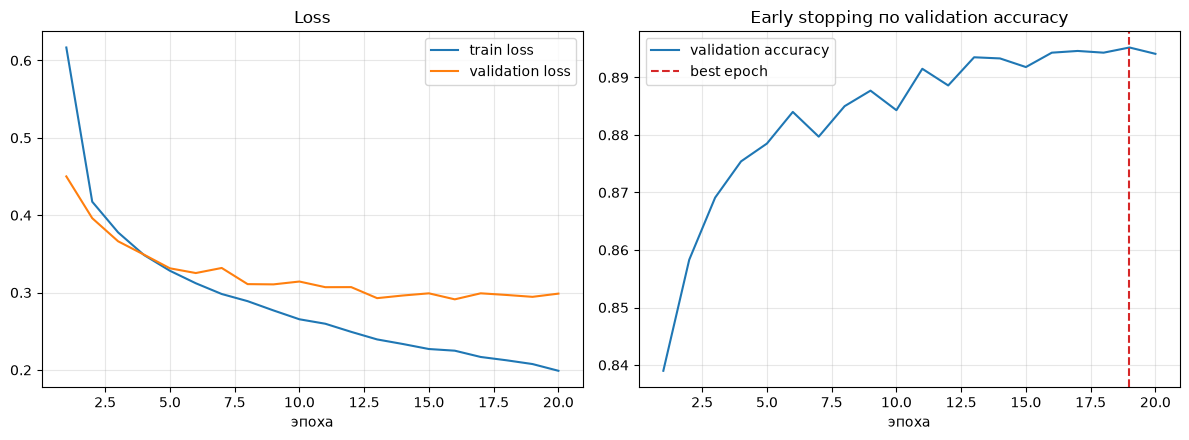

In [11]:
epochs = range(1, epochs_run + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(epochs, early_history["train_loss"], label="train loss")
axes[0].plot(epochs, early_history["val_loss"], label="validation loss")
axes[1].plot(epochs, early_history["val_acc"], label="validation accuracy")
axes[1].axvline(best_epoch, color="tab:red", linestyle="--", label="best epoch")
for axis in axes:
    axis.set_xlabel("эпоха")
    axis.grid(alpha=0.3)
    axis.legend()
axes[0].set_title("Loss")
axes[1].set_title("Early stopping по validation accuracy")
plt.tight_layout()
plt.show()

**Почему нужен `copy.deepcopy`.** Значения в обычном
`model.state_dict()` связаны с тензорами модели и продолжили бы изменяться при
следующих шагах оптимизатора. Глубокая копия фиксирует снимок лучшей эпохи.
Early stopping завершает обучение после серии эпох без значимого улучшения и
затем `load_state_dict(best_weights)` возвращает этот снимок. Это экономит время
и не оставляет модель в состоянии последней, потенциально переобученной эпохи.

---
## 8. Вывод

- Сравнивать оптимизаторы следует при одинаковых данных, инициализации, порядке
  батчей и бюджете обучения; learning rate нужно указывать явно.
- Для этой небольшой MLP Adam и AdamW обычно быстрее выходят примерно на 0.88,
  а SGD особенно выигрывает от momentum и/или большего числа эпох.
- `lr=1e-3` — разумная отправная точка для Adam, но выбор подтверждают validation
  loss и validation accuracy.
- `ReduceLROnPlateau` реагирует на фактическую validation loss, а
  `CosineAnnealingLR` меняет lr по заранее заданной траектории.
- Ручной early stopping должен хранить независимую копию лучших весов и
  восстанавливать её перед итоговой оценкой.

Конкретного победителя следует назвать по напечатанным метрикам своего запуска:
ожидаемые тенденции не заменяют измерение.